In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

input_folder = '/content/drive/MyDrive/Nlp resume ranker/resumes_techwiz'

os.makedirs(input_folder, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Tiền xử lý


Theo tìm hiểu thì OCR Vision nó chỉ thích hợp với ảnh thôi nên là muốn dùng khả năng phải chuyển pdf sang ảnh. Còn ở đây là docx mình sẽ sử dụng thư viện cơ bản.

In [ ]:
 !pip install python-docx

In [ ]:
import os
import pandas as pd
from docx import Document

def extract_text_from_docx(file_path):
    """
    Trích xuất toàn bộ văn bản từ Header, Body, Tables và Footer.
    Đảm bảo không bỏ sót thông tin liên hệ thường nằm ở đầu/cuối trang.
    """
    try:
        doc = Document(file_path)
        content = []

        # 1. Lấy text từ Header (Đầu trang)
        for section in doc.sections:
            header = section.header
            for para in header.paragraphs:
                if para.text.strip():
                    content.append(para.text.strip())

        # 2. Lấy text từ các đoạn văn trong Body
        for para in doc.paragraphs:
            if para.text.strip():
                content.append(para.text.strip())

        # 3. Lấy text từ các bảng (Xử lý thông minh tránh lặp ô gộp)
        for table in doc.tables:
            for row in table.rows:
                # Dùng list comprehension kết hợp dict.fromkeys để xóa trùng lặp
                # do ô gộp (merged cells) mà vẫn giữ nguyên thứ tự
                cells_text = [cell.text.strip() for cell in row.cells if cell.text.strip()]
                unique_cells = list(dict.fromkeys(cells_text))

                if unique_cells:
                    # Dùng dấu " | " để phân tách các cột, giúp BERT hiểu cấu trúc bảng tốt hơn
                    content.append(" | ".join(unique_cells))

        # 4. Lấy text từ Footer (Cuối trang)
        for section in doc.sections:
            footer = section.footer
            for para in footer.paragraphs:
                if para.text.strip():
                    content.append(para.text.strip())

        return "\n".join(content)

    except Exception as e:
        print(f"Lỗi khi đọc file {os.path.basename(file_path)}: {e}")
        return ""

# --- Cấu hình đường dẫn ---
data = []

if not os.path.exists(input_folder):
    print(f"Thư mục không tồn tại: {input_folder}")
else:
    # 3. Duyệt folder và xử lý
    files = [f for f in os.listdir(input_folder) if f.endswith('.docx')]
    print(f"Tìm thấy {len(files)} file .docx. Đang bắt đầu trích xuất...")

    for filename in files:
        file_path = os.path.join(input_folder, filename)
        resume_text = extract_text_from_docx(file_path)

        data.append({
            'file_name': filename,
            'raw_text': resume_text
        })

    # 4. Chuyển sang DataFrame
    df_resumes = pd.DataFrame(data)

    print("\n---Hoàn tất! ---")
    print(f"Tổng số resume đã xử lý: {len(df_resumes)}")
    display(df_resumes.head())

Tìm thấy 229 file .docx. Đang bắt đầu trích xuất...

---Hoàn tất! ---
Tổng số resume đã xử lý: 229


,file_name,raw_text
0,Adelina_Erimia_PMP1.docx,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC..."
1,Jennifer M. Conte.docx,Jennifer M. Conte\nSr. Java Developer/Architec...
2,Othman - Project Manager.docx,Othman\nPROJECT MANAGER\nAREAS OF EXPERTIESE:\...
3,Resume2018March.docx,Lorenzo Zackery / myvt.me@gmail.com /​215 . 98...
4,Randy Adams.docx,RANDY ADAMS\nSr. Java Developer – PG & E - San...


In [ ]:
import re
import unicodedata

def clean_text_for_bert_ner(text):
    if not text:
        return ""

    # 1. Chuẩn hóa Unicode (Cực kỳ quan trọng cho tiếng Việt)
    # Giúp đưa các ký tự có dấu về cùng một định dạng (ví dụ: 'á' không bị tách thành 'a' + dấu sắc)
    text = unicodedata.normalize('NFC', text)

    # 2. Xử lý các dấu đầu dòng đặc biệt trong Resume
    # Resume thường có các ký tự lạ như •, ➢, ■. Chúng ta nên đưa về dấu gạch ngang chuẩn
    # để BERT vẫn hiểu đó là một danh sách mục nhưng không bị lỗi từ điển (Out-of-vocab).
    text = re.sub(r'[•➢○●▪□■*]', '-', text)

    # 3. Loại bỏ các ký tự điều khiển không in được (Control characters)
    # Giữ lại tất cả dấu câu: . , ! ? : ; ( ) [ ] { } / \ - _ + @
    # Chúng ta chỉ loại bỏ những ký tự "rác" thực sự do lỗi trích xuất từ PDF/Docx
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] != 'C' or ch in '\n\t')

    # 4. Chuẩn hóa khoảng trắng
    # Thay thế các ký tự xuống dòng (\n), tab (\t) bằng khoảng trắng
    text = re.sub(r'[\t\r\n]+', ' ', text)
    # Thay thế nhiều khoảng trắng liên tiếp bằng một khoảng trắng duy nhất
    text = re.sub(r'\s+', ' ', text)


    return text.strip()

# Áp dụng vào DataFrame
df_resumes['cleaned_text'] = df_resumes['raw_text'].apply(clean_text_for_bert_ner)

print(df_resumes['cleaned_text'].head())

0    Adelina Erimia, PMP, Six Sigma Green Belt, SMC...
1    Jennifer M. Conte Sr. Java Developer/Architect...
2    Othman PROJECT MANAGER AREAS OF EXPERTIESE: IT...
3    Lorenzo Zackery / myvt.me@gmail.com /215 . 980...
4    RANDY ADAMS Sr. Java Developer – PG & E - San ...
Name: cleaned_text, dtype: object


In [ ]:
df_resumes.head()

,file_name,raw_text,cleaned_text
0,Adelina_Erimia_PMP1.docx,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC...","Adelina Erimia, PMP, Six Sigma Green Belt, SMC..."
1,Jennifer M. Conte.docx,Jennifer M. Conte\nSr. Java Developer/Architec...,Jennifer M. Conte Sr. Java Developer/Architect...
2,Othman - Project Manager.docx,Othman\nPROJECT MANAGER\nAREAS OF EXPERTIESE:\...,Othman PROJECT MANAGER AREAS OF EXPERTIESE: IT...
3,Resume2018March.docx,Lorenzo Zackery / myvt.me@gmail.com /​215 . 98...,Lorenzo Zackery / myvt.me@gmail.com /215 . 980...
4,Randy Adams.docx,RANDY ADAMS\nSr. Java Developer – PG & E - San...,RANDY ADAMS Sr. Java Developer – PG & E - San ...


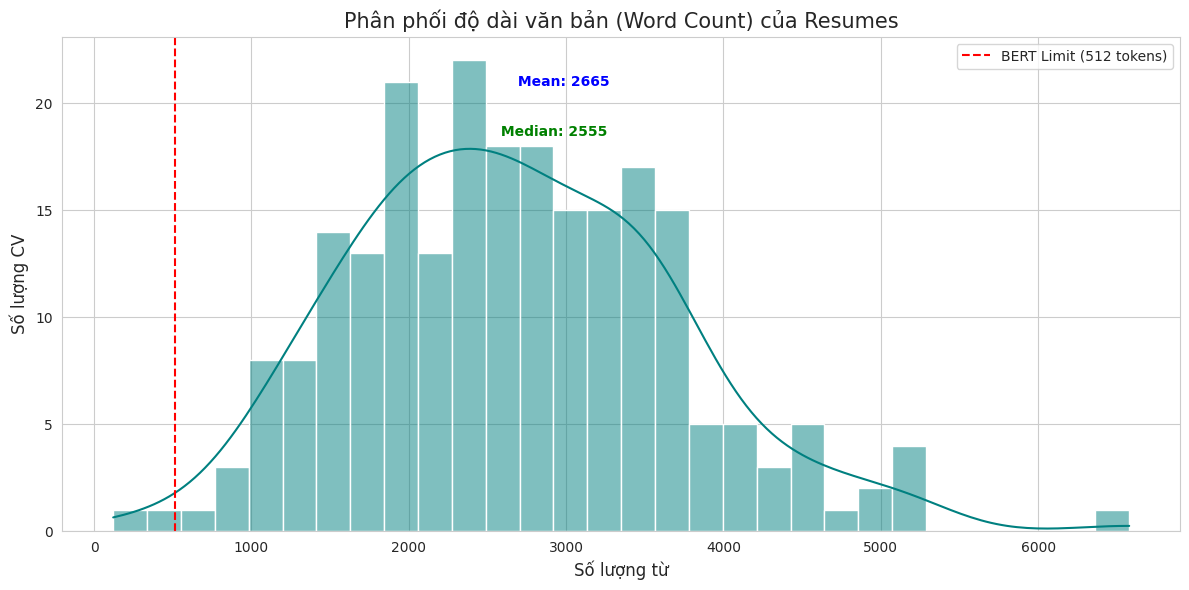

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán độ dài (số lượng từ) cho mỗi CV
# Chúng ta dùng split() để đếm số lượng từ cơ bản
df_resumes['word_count'] = df_resumes['cleaned_text'].apply(lambda x: len(str(x).split()))

# 2. Thiết lập cấu hình biểu đồ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Vẽ biểu đồ phân phối (Histogram + KDE)
ax = sns.histplot(df_resumes['word_count'], kde=True, color='teal', bins=30)

# 4. Thêm đường đánh dấu giới hạn 512 tokens của BERT
# Lưu ý: 1 từ thường tương đương ~1.3 tokens, nên 512 tokens ~ 400 từ
plt.axvline(x=512, color='red', linestyle='--', label='BERT Limit (512 tokens)')

# 5. Thêm các thông tin bổ sung
plt.title('Phân phối độ dài văn bản (Word Count) của Resumes', fontsize=15)
plt.xlabel('Số lượng từ', fontsize=12)
plt.ylabel('Số lượng CV', fontsize=12)
plt.legend()

# Hiển thị các chỉ số thống kê cơ bản lên biểu đồ
mean_val = df_resumes['word_count'].mean()
median_val = df_resumes['word_count'].median()
plt.text(mean_val, plt.ylim()[1]*0.9, f' Mean: {mean_val:.0f}', color='blue', fontweight='bold')
plt.text(median_val, plt.ylim()[1]*0.8, f' Median: {median_val:.0f}', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_short_cvs = df_resumes[df_resumes['word_count'] < 500]

print(f"Số lượng CV có dưới 500 từ: {len(df_short_cvs)}")
display(df_short_cvs.head())

Số lượng CV có dưới 500 từ: 2


,file_name,raw_text,cleaned_text,word_count
43,employer_Candidate33details.docx,Full Name | Candidate 33\nE-Mail: | Mounika102...,Full Name | Candidate 33 E-Mail: | Mounika1020...,122
105,Candidate93-resume_1_phplead.docx,Candidate 93\n+91 9427399390\nEmail: candidate...,Candidate 93 +91 9427399390 Email: candidate93...,407


In [ ]:
df_resumes = df_resumes.drop(index=44).reset_index(drop=True)

In [ ]:
df_resumes.shape

(228, 4)

In [ ]:
# 2. Lọc ra các CV dài hơn 4000 từ (ngưỡng bắt đầu vùng outlier)
# Check thủ công các CV
df_outliers = df_resumes[df_resumes['word_count'] > 2000][['file_name', 'word_count']]

# 3. Sắp xếp từ dài nhất xuống thấp dần để xem những "ca khó" nhất trước
df_outliers = df_outliers.sort_values(by='word_count', ascending=False)

# 4. Hiển thị kết quả
print(f"Số lượng CV nghi vấn ( > 2000 từ): {len(df_outliers)}")
print("-" * 30)
print(df_outliers.head(20)) # Xem 20 cái dài nhất

Số lượng CV nghi vấn ( > 2000 từ): 163
------------------------------
                                        file_name  word_count
92                        Candidate81_resume.docx        6578
101                              Candidate90.docx        5232
21                               Candidate13.docx        5208
90                               Candidate79.docx        5183
160             Candidate145_Project_Manager.docx        5125
102                              Candidate91.docx        4932
74                    Candidate63 BSA Resume.docx        4909
218                             Candidate203.docx        4743
212                         candidate197java.docx        4634
12                              Candidate_04.docx        4585
169                             Candidate154.docx        4510
89                               Candidate78.docx        4475
157                Candidate142_Java_8+ Year.docx        4472
126  Candidate 114 Full Stack Java Developer.docx        4394


In [ ]:
count_3000 = len(df_resumes[df_resumes['word_count'] > 2000])
print(f"Số lượng CV có trên 2000 từ: {count_3000}")

Số lượng CV có trên 2000 từ: 163


In [ ]:
df_resumes.head()

,file_name,raw_text,cleaned_text,word_count
0,Adelina_Erimia_PMP1.docx,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC...","Adelina Erimia, PMP, Six Sigma Green Belt, SMC...",825
1,Jennifer M. Conte.docx,Jennifer M. Conte\nSr. Java Developer/Architec...,Jennifer M. Conte Sr. Java Developer/Architect...,882
2,Othman - Project Manager.docx,Othman\nPROJECT MANAGER\nAREAS OF EXPERTIESE:\...,Othman PROJECT MANAGER AREAS OF EXPERTIESE: IT...,1180
3,Resume2018March.docx,Lorenzo Zackery / myvt.me@gmail.com /​215 . 98...,Lorenzo Zackery / myvt.me@gmail.com /215 . 980...,1645
4,Randy Adams.docx,RANDY ADAMS\nSr. Java Developer – PG & E - San...,RANDY ADAMS Sr. Java Developer – PG & E - San ...,3613


In [ ]:
specific_file_name = 'Candidate81_resume.docx'
filtered_text = df_resumes[df_resumes['file_name'] == specific_file_name]['cleaned_text']

if not filtered_text.empty:
    display(filtered_text.iloc[0])
else:
    print(f"Không tìm thấy file '{specific_file_name}' trong DataFrame.")

'Candidate81 Candidate81.bsa12@gmail.com (503) 922-3601 PROFESSIONAL Summary Over 12 years of experience as Business Analyst in Requirement gathering, elicitation, Business, Functional and Technical Requirements documentation (BRD, FRD, TRD), Use Cases, Product backlog, Epics, User Stories, Acceptance Criteria, Story points, Agile (Scrum, XP), RUP, CMMI and Waterfall Methodologies, Business Process Management and Reengineering (BPM/BPR), Design documentation, logical and physical design (LSDD, PSDD), Flow charts, UML, Process flows, AS-IS and TO-BE diagrams, Activity diagrams, Sequence diagrams, Data migration, Data mapping, Data extraction, Data analytics, Data mining, Predictive analysis, ETL, Data warehouse modeling, Data Marts, Business Intelligence (BI), Reporting, Various BI tools- Tableau, OBIEE, Cognos, Business Objects, Crystal reports, Reporting work bench, Various database like Oracle, Sybase, DB2, Access, SQL, various programming languages like Java/.Net/C++/Cobol, Code rev

# Tải về df_resumes

In [ ]:
output_path_for_df_resumes = '/content/drive/MyDrive/Nlp resume ranker/df_resumes.csv'
df_resumes.to_csv(output_path_for_df_resumes, index=False)
print(f"'df_resumes' đã được lưu thành công tại: {output_path_for_df_resumes}")

# Phân đoạn và tóm tắt văn bản

In [ ]:
import pandas as pd

output_path_for_df_resumes = '/content/drive/MyDrive/Nlp resume ranker/df_resumes.csv'
df_resumes = pd.read_csv(output_path_for_df_resumes)
print(f"'df_resumes' đã được tải thành công từ: {output_path_for_df_resumes}")
display(df_resumes.head())

'df_resumes' đã được tải thành công từ: /content/drive/MyDrive/Nlp resume ranker/df_resumes.csv


,file_name,raw_text,cleaned_text,word_count
0,Adelina_Erimia_PMP1.docx,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC...","Adelina Erimia, PMP, Six Sigma Green Belt, SMC...",825
1,Jennifer M. Conte.docx,Jennifer M. Conte\nSr. Java Developer/Architec...,Jennifer M. Conte Sr. Java Developer/Architect...,882
2,Othman - Project Manager.docx,Othman\nPROJECT MANAGER\nAREAS OF EXPERTIESE:\...,Othman PROJECT MANAGER AREAS OF EXPERTIESE: IT...,1180
3,Resume2018March.docx,Lorenzo Zackery / myvt.me@gmail.com /​215 . 98...,Lorenzo Zackery / myvt.me@gmail.com /215 . 980...,1645
4,Randy Adams.docx,RANDY ADAMS\nSr. Java Developer – PG & E - San...,RANDY ADAMS Sr. Java Developer – PG & E - San ...,3613


In [ ]:
specific_file_name = 'Candidate206_Business Analyst.docx'
filtered_text = df_resumes[df_resumes['file_name'] == specific_file_name]['cleaned_text']

if not filtered_text.empty:
    display(filtered_text.iloc[0])
else:
    print(f"Không tìm thấy file '{specific_file_name}' trong DataFrame.")

"Candidate206 Email Id:candidate20650@gmail.com Contact: 650-417-3184 Professional Summary: 7+ years of experience, working as Business Analyst in various Domains including Airlines, Healthcare, and Banking. Extensive Knowledge of Software Development Life Cycle (SDLC), Development methodologies like AGILE, Waterfall. Experienced in Iterative Development Frameworks such as Rational Unified Process, Agile and Scrum. Hands on experience Business and Requirements Analysis, Business Process modeling and Project planning. Experienced in Eliciting Business Requirements and Expertise in Transforming Business requirements in to Functional requirement documents and Designing business models using UML Diagrams. Experienced in facilitating requirement elicitation techniques such as Joint Application Development (JAD), Rapid Application Development (RAD) and Joint Requirement Planning (JRP). Proficient in analyzing and Creating Use Cases, Use Case Diagrams, Activity diagrams, Class diagrams, Data 

In [ ]:
!pip install -U google-genai

In [ ]:
import os
import re
import time
import json
import pandas as pd
from google import genai
from google.colab import userdata
from tqdm.notebook import tqdm  # Ưu tiên dùng bản notebook cho Colab
from concurrent.futures import ThreadPoolExecutor, as_completed

# -------------------------------------------------------------------
# 0. CẤU HÌNH API
# -------------------------------------------------------------------
GOOGLE_API_KEY = userdata.get('GOOGLEAISTUDIO_API_KEY')
client = genai.Client(api_key=GOOGLE_API_KEY)

In [ ]:
import re

def extract_tag(tag_name, text_content, clean_url=True):
    """
    Trích xuất nội dung giữa các tag và làm sạch dữ liệu.
    Cải tiến: Xử lý trường hợp LLM bị cắt ngang (thiếu tag đóng).
    """
    # 1. Thử tìm cặp tag đầy đủ trước
    full_pattern = rf"<\s*{re.escape(tag_name)}\s*>(.*?)<\s*/\s*{re.escape(tag_name)}\s*>"
    match = re.search(full_pattern, text_content, re.DOTALL | re.IGNORECASE)

    if match:
        res = match.group(1).strip()
    else:
        # 2. Nếu không có tag đóng, tìm từ tag mở cho đến hết văn bản hoặc tag mở tiếp theo
        # Đây là cơ chế fallback khi LLM bị truncated (cắt ngang)
        open_pattern = rf"<\s*{re.escape(tag_name)}\s*>(.*?)(?=<\s*/?\s*\w+\s*>|$)"
        match_fallback = re.search(open_pattern, text_content, re.DOTALL | re.IGNORECASE)
        if match_fallback:
            res = match_fallback.group(1).strip()
        else:
            return ""

    # 3. Xóa Markdown artifacts
    res = re.sub(r"```(?:xml|json|html|markdown|)?", "", res, flags=re.IGNORECASE).strip()
    res = res.replace('```', '').strip()

    # 4. Xóa URL ngoại trừ mục thông tin cá nhân (để giữ LinkedIn)
    if clean_url and tag_name.upper() != "INFORMATION_SECTION":
        url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
        res = re.sub(url_pattern, '', res)

    # 5. Làm phẳng văn bản
    res = re.sub(r'\s+', ' ', res)

    return res.strip()

In [ ]:
# -------------------------------------------------------------------
# 1. HÀM XỬ LÝ CV > 2000 TỪ (PHÂN ĐOẠN + TÓM TẮT)
# -------------------------------------------------------------------
def segment_and_summarize_cv(text):
    system_instruction = """
    Role: Expert NLP Data Engineer.
    Task: Segment & Summarize resumes into 5 tags. Keep 100% tech identity and results.

    1. TAGS:
    <INFORMATION_SECTION>: Name, Phone, Email, Location, LinkedIn, job_title, years_of_experience (float). Format: "Label: [Value], Label[Value],...". Strict: Omit missing, no placeholders.
    <SUMMARY_SECTION>: 6-8 sentences dense profile.
    <SKILLS_SECTION>: Full tech stack.
    <EXPERIENCE_SECTION>: Structured work/projects.
    <EDUCATION_SECTION>: Degrees, certs, achievements. If missing, return empty tag.

    2. RULES:
    - Dates: MM/YYYY - MM/YYYY (or Present). Use YYYY if month missing.
    - Fidelity: 100% tech name accuracy (keep typos). No hallucination.
    - Content: Retain QUANTITATIVE RESULTS (%, $, time) and ARCHITECTURE. Target 800-2000 words.
    - Strict: No placeholders (N/A, Unavailable). If missing, omit or return empty tag.

    3. EXPERIENCE BLOCK:
    - Header: [Company/Project] | [Role] | [Dates] (Use literal brackets, omit if missing.).
    - Body: Dense paragraph: "Action -> Result".
    - Footer: Environment: [Tool1, Tool2, ...] (Mandatory literal brackets; omit if empty).
    """
    user_prompt = f"Input Long Resume (>2000 words) to segment and summarize:\n{text}"

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite-preview",
            contents=user_prompt,
            config={
                'system_instruction': system_instruction,
                'temperature': 0,
                'top_p': 0.95,
            }
        )
        content = response.text
        return {
            "information_section": extract_tag("INFORMATION_SECTION", content),
            "summary_objective": extract_tag("SUMMARY_SECTION", content),
            "technical_skills": extract_tag("SKILLS_SECTION", content),
            "work_experience": extract_tag("EXPERIENCE_SECTION", content),
            "education_certifications": extract_tag("EDUCATION_SECTION", content)
        }
    except Exception as e:
        return {"error": str(e)}

In [ ]:
def segment_cv(text):
    system_instruction = """
    Role: Expert NLP Data Engineer.
    Task: SEGMENT resumes into 5 tags. 100% integrity. ZERO Summarization.

    1. TAGS:
    <INFORMATION_SECTION>: Name, Phone, Email, Location, LinkedIn, job_title, years_of_experience (float). Format: "Label: [Value], Label[Value],...". Strict: Omit missing, no placeholders.
    <SUMMARY_SECTION>: 6-8 sentences dense profile.
    <SKILLS_SECTION>: Full tech stack.
    <EXPERIENCE_SECTION>: Structured work/projects.
    <EDUCATION_SECTION>: Degrees, certs, achievements.If missing, return empty tag.

    2. RULES:
    - Zero Summarization: Preserve every original word/detail. No grammar fixes.
    - Dates: MM/YYYY - MM/YYYY (or Present). Use YYYY if month missing.
    - Entity Protection: 100% tech name fidelity (C++, .NET, etc.).
    - Prose-Style: Convert bullets into dense technical paragraphs for embeddings.
    - Clean-up: Omit page numbers, redundant headers, duplicate contact info.
    - No Placeholders: No placeholders (N/A, Unavailable). If missing, omit or return empty tag.

    3. EXPERIENCE BLOCK:
    - Header: [Company/Project] | [Role] | [Dates] (Use literal brackets, omit if missing).
    - Body: Original text reformatted into dense paragraph.
    - Footer: Environment: [Tool1, Tool2, ...] (Mandatory literal []; omit if empty).
    """
    user_prompt = f"Input Resume Text to segment:\n{text}"

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite-preview",
            contents=user_prompt,
            config={
                'system_instruction': system_instruction,
                'temperature': 0,
                'top_p': 0.95,
            }
        )
        content = response.text
        return {
            "information_section": extract_tag("INFORMATION_SECTION", content),
            "summary_objective": extract_tag("SUMMARY_SECTION", content),
            "technical_skills": extract_tag("SKILLS_SECTION", content),
            "work_experience": extract_tag("EXPERIENCE_SECTION", content),
            "education_certifications": extract_tag("EDUCATION_SECTION", content)
        }
    except Exception as e:
        return {"error": str(e)}

In [ ]:
df_resumes.head()

,file_name,raw_text,cleaned_text,word_count
0,Adelina_Erimia_PMP1.docx,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC...","Adelina Erimia, PMP, Six Sigma Green Belt, SMC...",825
1,Jennifer M. Conte.docx,Jennifer M. Conte\nSr. Java Developer/Architec...,Jennifer M. Conte Sr. Java Developer/Architect...,882
2,Othman - Project Manager.docx,Othman\nPROJECT MANAGER\nAREAS OF EXPERTIESE:\...,Othman PROJECT MANAGER AREAS OF EXPERTIESE: IT...,1180
3,Resume2018March.docx,Lorenzo Zackery / myvt.me@gmail.com /​215 . 98...,Lorenzo Zackery / myvt.me@gmail.com /215 . 980...,1645
4,Randy Adams.docx,RANDY ADAMS\nSr. Java Developer – PG & E - San...,RANDY ADAMS Sr. Java Developer – PG & E - San ...,3613


In [ ]:
import os
import time
import json
import pandas as pd
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# 1. KHỞI TẠO DATAFRAME ĐẦU RA (Giữ nguyên cấu trúc)
df_segmented = df_resumes[['file_name']].copy()
sections = ['information_section', 'summary_objective', 'technical_skills', 'work_experience', 'education_certifications']
for col in sections: df_segmented[col] = ""
df_segmented['new_word_count'] = 0

output_folder = '/content/drive/MyDrive/Nlp resume ranker/resumes_segment4'
os.makedirs(output_folder, exist_ok=True)

def process_row(idx_row):
    index, row = idx_row
    word_count = row['word_count']
    text = row['cleaned_text']
    file_name = row['file_name']

    base_name = os.path.splitext(str(file_name))[0]
    safe_fname = "".join([c for c in base_name if c.isalnum() or c in (' ', '_', '-')]).strip()[:50]
    file_path = os.path.join(output_folder, f"{safe_fname}_segmented.json")

    # Caching
    if os.path.exists(file_path):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                if data and "error" not in data and any(data.values()):
                    return index, data
        except: pass

    max_retries = 5 # Tăng số lần thử lại
    for attempt in range(max_retries):
        try:
            if word_count > 2000:
                result = segment_and_summarize_cv(text)
            else:
                result = segment_cv(text)

            if "error" in result:
                raise Exception(result["error"])

            content_check = [len(str(v)) for k, v in result.items() if k != "error"]
            if sum(content_check) > 50:
                with open(file_path, 'w', encoding='utf-8') as f:
                    json.dump(result, f, ensure_ascii=False, indent=4)
                return index, result
            else:
                raise Exception("LLM output detected but tags were empty or too short.")

        except Exception as e:
            err_msg = str(e)
            # Xử lý cả Rate Limit (429) và Service Unavailable (503)
            if "429" in err_msg or "503" in err_msg:
                wait_time = (attempt + 1) * 30 # Chờ tăng dần: 30s, 60s, 90s...
                time.sleep(wait_time)
            else:
                time.sleep(5)

            if attempt == max_retries - 1:
                return index, {"error": f"Failed after {max_retries} attempts: {err_msg}"}

    return index, {"error": "Unknown failure"}

In [ ]:

# 3. THỰC THI VÀ CẬP NHẬT THỜI GIAN THỰC
print(f"Đang xử lý {len(df_resumes)} CV...")
rows = list(df_resumes.iterrows())
failed_indices = []

# Dùng try...except để hứng lệnh STOP (KeyboardInterrupt)
try:
    # Chỉnh max_workers=1 để an toàn với Rate Limit của Gemini Flash Lite
    with ThreadPoolExecutor(max_workers=1) as executor:
        futures = {executor.submit(process_row, row): row for row in rows}

        # tqdm sẽ bao bọc việc lấy kết quả
        pbar = tqdm(as_completed(futures), total=len(rows), desc="Đang quét CV")

        for future in pbar:
            index, res = future.result()

            if res and "error" not in res:
                # --- CẬP NHẬT TRỰC TIẾP VÀO DATAFRAME TẠI ĐÂY ---
                total_words = 0
                for col in sections:
                    content = res.get(col, " ")
                    df_segmented.at[index, col] = content
                    total_words += len(str(content).split())
                df_segmented.at[index, 'new_word_count'] = total_words
            else:
                failed_indices.append(index)
                print(f"\n[!] Lỗi tại index {index}: {res.get('error')}")

except KeyboardInterrupt:
    print("\n[!] Bạn đã dừng chương trình thủ công! Đang chuẩn bị lưu dữ liệu đã xử lý...")

finally:
    # 4. LƯU CSV CUỐI CÙNG
    final_path = os.path.join(output_folder, 'df_resumes_segmented_final.csv')
    df_segmented.to_csv(final_path, index=False)

    print("-" * 40)
    processed_count = (df_segmented['new_word_count'] > 0).sum()
    print(f"Hoàn tất: {processed_count}/{len(df_resumes)} CV.")
    print(f"Đường dẫn file: {final_path}")
    if failed_indices:
        print(f"Các index bị lỗi ({len(failed_indices)}): {failed_indices}")

display(df_segmented[['file_name', 'new_word_count']].head())

Đang xử lý 228 CV...


Đang quét CV:   0%|          | 0/228 [00:00<?, ?it/s]

----------------------------------------
Hoàn tất: 228/228 CV.
Đường dẫn file: /content/drive/MyDrive/Nlp resume ranker/resumes_segment4/df_resumes_segmented_final.csv


,file_name,new_word_count
0,Adelina_Erimia_PMP1.docx,780
1,Jennifer M. Conte.docx,1124
2,Othman - Project Manager.docx,1196
3,Resume2018March.docx,1644
4,Randy Adams.docx,844


In [ ]:
df_segmented.head()

,file_name,information_section,summary_objective,technical_skills,work_experience,education_certifications,new_word_count
0,Adelina_Erimia_PMP1.docx,"Name: Adelina Erimia, Phone: 469-331-7851, Ema...",Experienced project manager offering over 10 y...,"MS Project, PPM, Smartsheet, Microsoft Word, E...","[Project Management Institute (PMI), Savannah ...","Universitatea de Vest, Romania - BA - Business...",780
1,Jennifer M. Conte.docx,"Name: Jennifer M. Conte, job_title: Sr. Java D...",Jennifer M. Conte is a highly experienced Sr. ...,"Java/J2EE, JDK 1.8, Java 8, Java 6, C++, Angul...",[Macrosolid] | [Sr. JAVA Application Developer...,"Bachelor of Electronic Engineering, Beijing Un...",1124
2,Othman - Project Manager.docx,"Name: Othman, job_title: PROJECT MANAGER, year...",Intuitive IT management professional offering ...,"IT Management, Project Management, Organizatio...",[KO Satellite Inc.] | [IT Manager] | [2007 – P...,"Masters of Information System Management, Kell...",1196
3,Resume2018March.docx,"Name: Lorenzo Zackery, Phone: 215 . 980 . 1011...",I've been a WordPress Developer for 13 years n...,WordPress theme / plugin development & configu...,[Various WordPress Consulting Projects] | [Con...,,1644
4,Randy Adams.docx,"Name: Randy Adams, Phone: [Missing], Email: ra...",Senior Java Developer with over 8 years of com...,"Languages: Core Java, Java (Generics), JavaScr...",[PG & E] | [Sr. Java Developer] | [04/2015 - P...,"Master of Science and Engineering, Brandeis Un...",844


# Trực quan hóa dữ liệu

### Trực quan hóa độ dài văn bản sau khi Segment

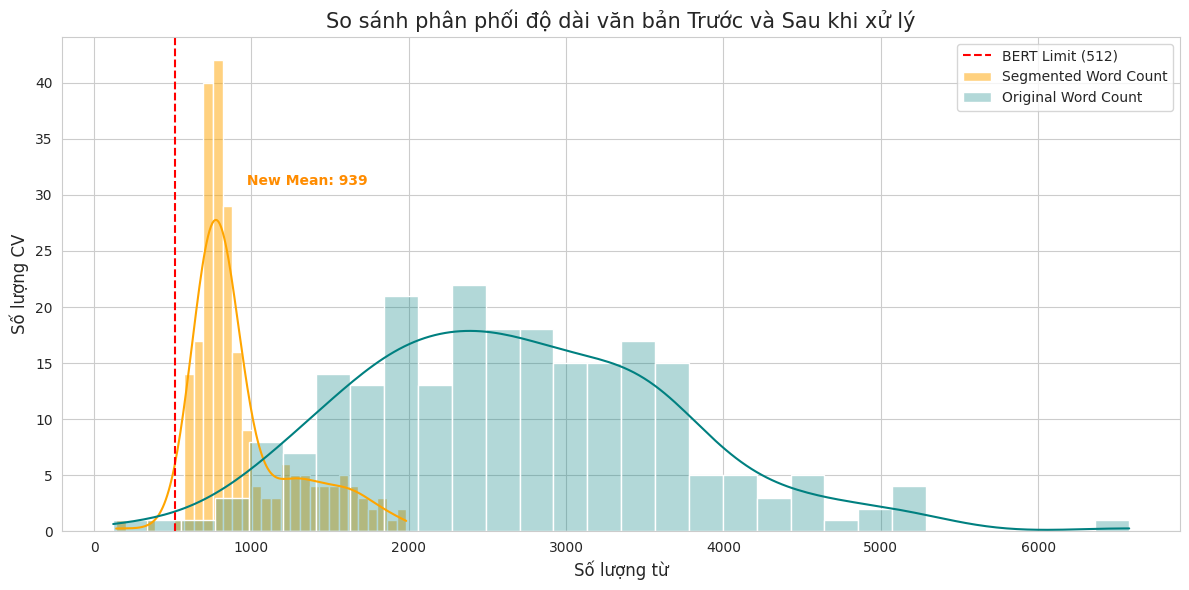

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập cấu hình biểu đồ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 2. Vẽ biểu đồ phân phối cho df_segmented
sns.histplot(df_segmented['new_word_count'], kde=True, color='orange', bins=30, label='Segmented Word Count')

# 3. Vẽ thêm phân phối cũ để so sánh (tùy chọn)
sns.histplot(df_resumes['word_count'], kde=True, color='teal', bins=30, alpha=0.3, label='Original Word Count')

# 4. Thêm các đường đánh dấu
plt.axvline(x=512, color='red', linestyle='--', label='BERT Limit (512)')

# 5. Thông tin bổ sung
plt.title('So sánh phân phối độ dài văn bản Trước và Sau khi xử lý', fontsize=15)
plt.xlabel('Số lượng từ', fontsize=12)
plt.ylabel('Số lượng CV', fontsize=12)
plt.legend()

# Hiển thị thống kê
mean_new = df_segmented['new_word_count'].mean()
plt.text(mean_new, plt.ylim()[1]*0.7, f' New Mean: {mean_new:.0f}', color='darkorange', fontweight='bold')

plt.tight_layout()
plt.show()

**Reasoning**:
I will calculate the compression ratio by comparing the original word counts with the new word counts after LLM processing, then visualize the distribution and display descriptive statistics to evaluate information density.



--- Thống kê Tỉ lệ Nén (Compression Ratio) ---
Trung bình (Mean): 0.4418
Trung vị (Median): 0.2939
Nhỏ nhất (Min): 0.1104
Lớn nhất (Max): 1.2630
----------------------------------------


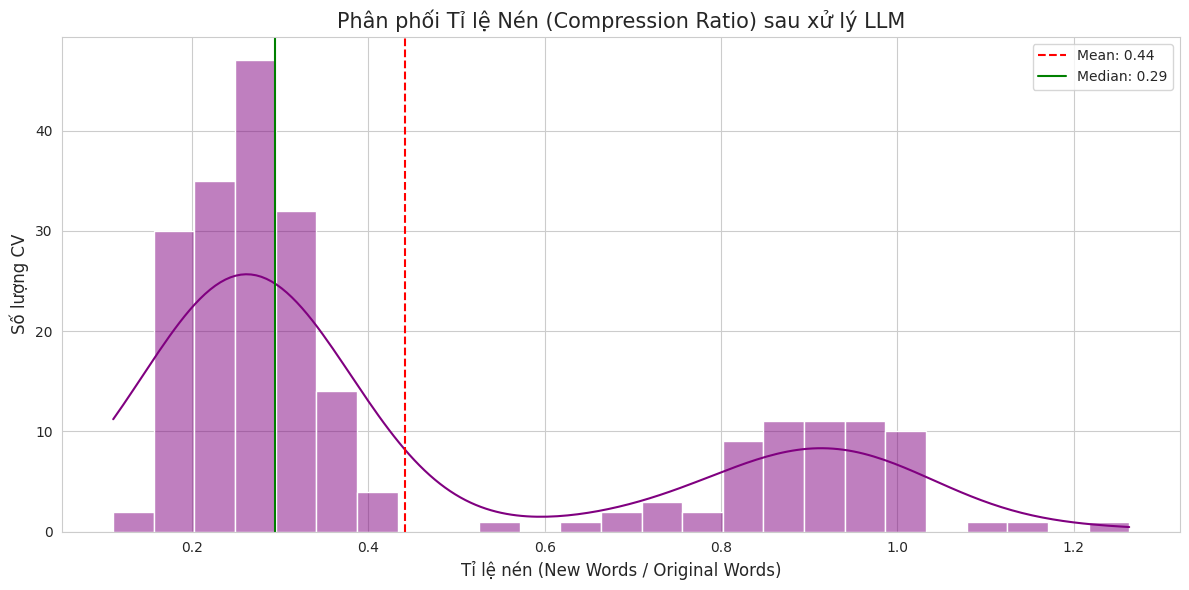

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Compression Ratio
# Compression Ratio = New Word Count / Original Word Count
df_segmented['compression_ratio'] = df_segmented['new_word_count'] / df_resumes['word_count']

# 2. Descriptive Statistics
stats = df_segmented['compression_ratio'].describe()
print("--- Thống kê Tỉ lệ Nén (Compression Ratio) ---")
print(f"Trung bình (Mean): {stats['mean']:.4f}")
print(f"Trung vị (Median): {stats['50%']:.4f}")
print(f"Nhỏ nhất (Min): {stats['min']:.4f}")
print(f"Lớn nhất (Max): {stats['max']:.4f}")
print("-" * 40)

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot distribution
sns.histplot(df_segmented['compression_ratio'], kde=True, color='purple', bins=25)

# Add vertical lines for mean and median
plt.axvline(stats['mean'], color='red', linestyle='--', label=f'Mean: {stats["mean"]:.2f}')
plt.axvline(stats['50%'], color='green', linestyle='-', label=f'Median: {stats["50%"]:.2f}')

plt.title('Phân phối Tỉ lệ Nén (Compression Ratio) sau xử lý LLM', fontsize=15)
plt.xlabel('Tỉ lệ nén (New Words / Original Words)', fontsize=12)
plt.ylabel('Số lượng CV', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

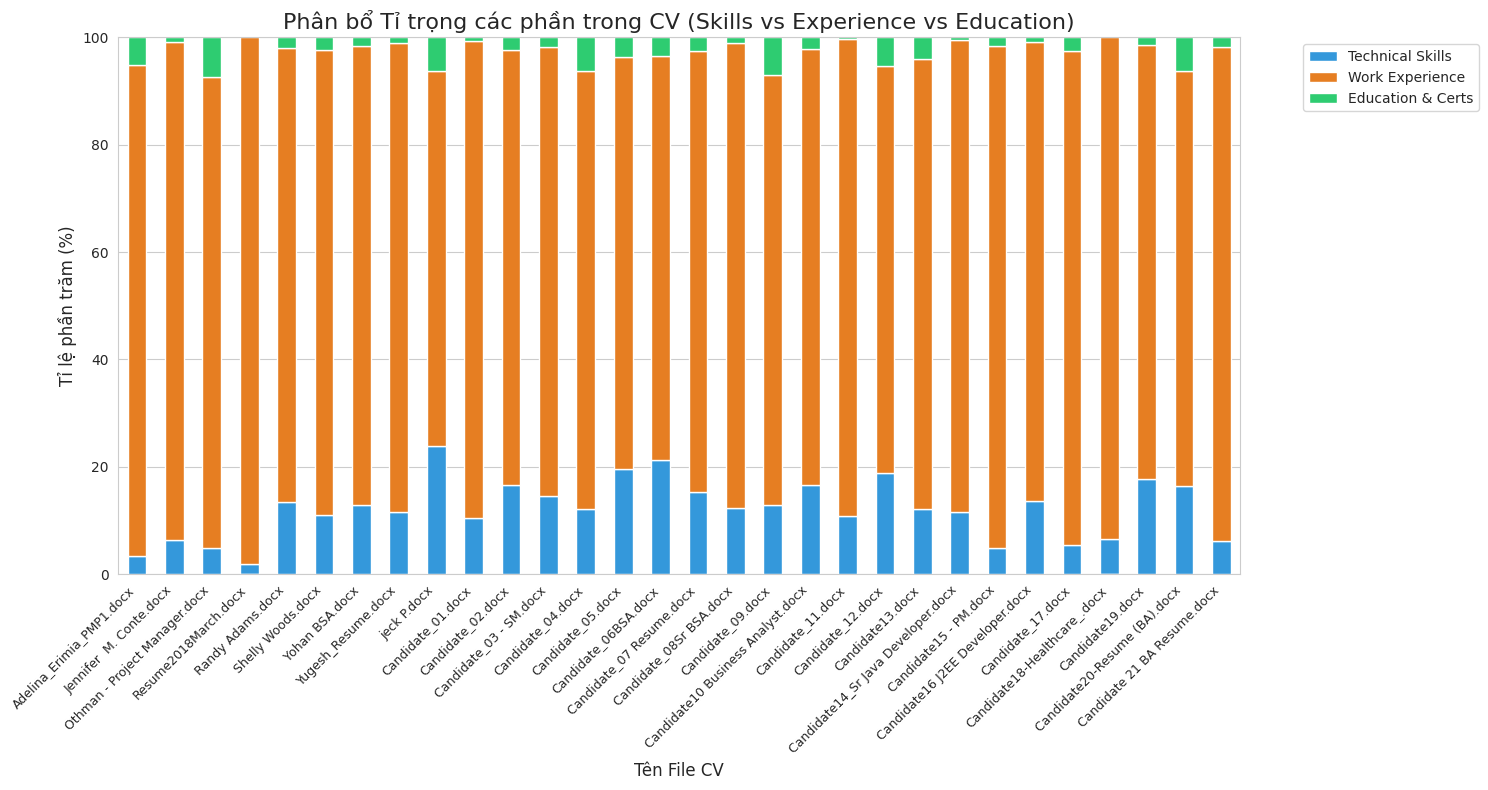

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate word counts for each section
sections_to_plot = ['technical_skills', 'work_experience', 'education_certifications']
plot_data = pd.DataFrame()

for col in sections_to_plot:
    plot_data[col] = df_segmented[col].apply(lambda x: len(str(x).split()))

# 2. Calculate relative percentages
# Sum of the three sections
section_sum = plot_data.sum(axis=1)
# Avoid division by zero
section_sum = section_sum.replace(0, 1)

for col in sections_to_plot:
    plot_data[f'{col}_pct'] = (plot_data[col] / section_sum) * 100

# 3. Select a sample for visualization (e.g., first 30 resumes)
sample_size = 30
df_sample = plot_data[[f'{col}_pct' for col in sections_to_plot]].head(sample_size)
df_sample.index = df_segmented['file_name'].head(sample_size)

# 4. Plot Stacked Bar Chart
plt.figure(figsize=(15, 8))
colors = ['#3498db', '#e67e22', '#2ecc71'] # Blue, Orange, Green

df_sample.plot(kind='bar', stacked=True, color=colors, ax=plt.gca())

# 5. Add details
plt.title('Phân bổ Tỉ trọng các phần trong CV (Skills vs Experience vs Education)', fontsize=16)
plt.xlabel('Tên File CV', fontsize=12)
plt.ylabel('Tỉ lệ phần trăm (%)', fontsize=12)
plt.legend(['Technical Skills', 'Work Experience', 'Education & Certs'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Word Cloud cho Kỹ năng Kỹ thuật (Technical Skills)

### Subtask:
Tạo đám mây từ ngữ từ cột 'technical_skills' để nhận diện các công nghệ phổ biến nhất hiện có trong bộ dữ liệu ứng viên.


In [ ]:
!pip install wordcloud

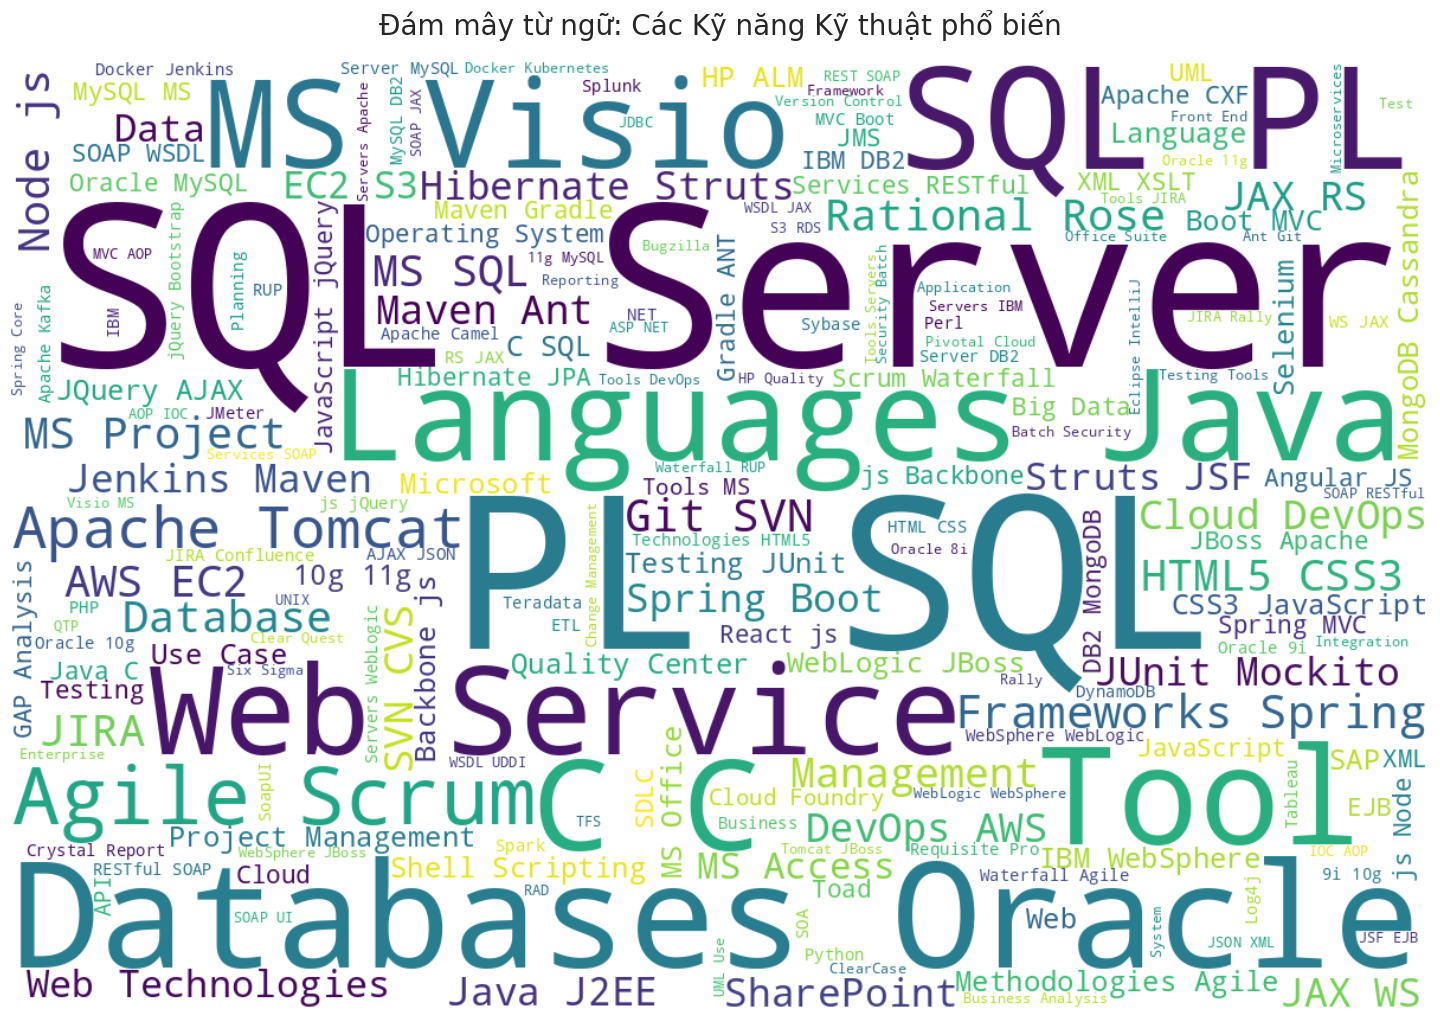

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all technical skills into a single text block
# Handling nulls or non-string values by converting to empty strings
skills_text = " ".join(df_segmented['technical_skills'].fillna("").astype(str))

# 2. Initialize and Generate WordCloud
wc = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=200,
    contour_width=3,
    contour_color='steelblue'
).generate(skills_text)

# 3. Display the visualization
plt.figure(figsize=(15, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Đám mây từ ngữ: Các Kỹ năng Kỹ thuật phổ biến', fontsize=20, pad=20)
plt.tight_layout(pad=0)
plt.show()

## Phân phối Số năm Kinh nghiệm (Seniority Distribution)

### Subtask:
Trích xuất số năm kinh nghiệm từ 'information_section' bằng Regex và vẽ biểu đồ Histogram để đánh giá thâm niên của tập ứng viên.


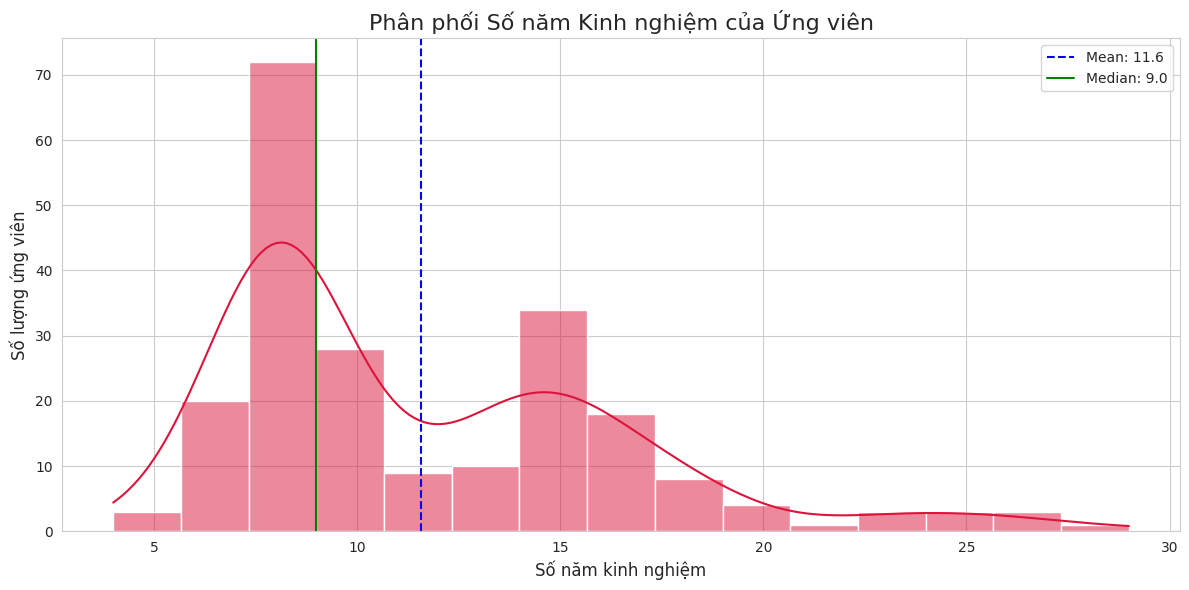

--- Thống kê Số năm kinh nghiệm ---
count    217.000000
mean      11.570645
std        4.779730
min        4.000000
25%        8.000000
50%        9.000000
75%       15.000000
max       29.000000
Name: years_of_exp, dtype: float64


In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define function to extract years of experience
def extract_experience(info_text):
    if not isinstance(info_text, str):
        return np.nan
    # Pattern to match 'years_of_experience: [Value]'
    match = re.search(r'years_of_experience:\s*([\d.]+)', info_text, re.IGNORECASE)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            return np.nan
    return np.nan

# 2. Apply extraction and create new column
df_segmented['years_of_exp'] = df_segmented['information_section'].apply(extract_experience)

# Handle missing values by filling with 0 for visualization if necessary,
# but here we'll let seaborn handle NaNs (they won't be plotted)

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 4. Plot Histogram with KDE
sns.histplot(df_segmented['years_of_exp'].dropna(), kde=True, color='crimson', bins=15)

# 5. Add titles and labels
plt.title('Phân phối Số năm Kinh nghiệm của Ứng viên', fontsize=16)
plt.xlabel('Số năm kinh nghiệm', fontsize=12)
plt.ylabel('Số lượng ứng viên', fontsize=12)

# Add descriptive statistics to the plot
mean_exp = df_segmented['years_of_exp'].mean()
median_exp = df_segmented['years_of_exp'].median()
plt.axvline(mean_exp, color='blue', linestyle='--', label=f'Mean: {mean_exp:.1f}')
plt.axvline(median_exp, color='green', linestyle='-', label=f'Median: {median_exp:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

# Display summary stats
print("--- Thống kê Số năm kinh nghiệm ---")
print(df_segmented['years_of_exp'].describe())
